<div style="display: flex; align-items: center; width: 100%;">  
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">    
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>  
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Feature Importance
    </h1>
  </div>  
</div>

Which features actually drive a model? RiskLabAI implements the three classic
measures from de Prado:

- **MDI** (Mean Decrease Impurity) — in-sample, tree-internal; fast but optimistic,
- **MDA** (Mean Decrease Accuracy) — out-of-sample permutation importance,
- **SFI** (Single Feature Importance) — train on each feature alone.

We test them on a synthetic dataset with **known** informative, redundant, and
noise features, so we can watch each method rank the real signal — and see their
characteristic differences.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 8.

## 1. A dataset with known ground truth

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using RiskLabAI
using Random, Statistics, DataFrames, Plots
gr()
theme(:default)                                   # theme-adaptive figures (legible on GitHub light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)

  Activating project at `C:\arian\risklabai\Notebooks.jl`


In [2]:
x, y, names = get_test_dataset(; n_features = 15, n_informative = 6,
    n_redundant = 2, n_samples = 1000, random_state = 1)

feature_type(nm) = startswith(nm, "I_") ? "informative" :
                   startswith(nm, "R_") ? "redundant" : "noise"
types = feature_type.(names)

n_signal = count(!=("noise"), types)
n_informative = count(==("informative"), types)
n_redundant   = count(==("redundant"), types)
println("$(n_informative) informative + $(n_redundant) redundant = $(n_signal) signal, ",
        "$(length(types) - n_signal) noise")

6 informative + 2 redundant = 8 signal, 7 noise


## 2. A shared plotting helper

We sort features by importance and colour them by their true type — a good
method should pile the **informative** (green) and **redundant** (blue) features
on the left and leave **noise** (grey) on the right.

In [3]:
type_color(t) = t == "informative" ? :seagreen : t == "redundant" ? :steelblue : :lightgray

function plot_importance(importance, ttl)
    order = sortperm(importance; rev = true)
    bar(1:length(importance), importance[order]; legend = false,
        color = permutedims(type_color.(types[order])),
        xlabel = "feature (ranked by importance)", ylabel = "importance",
        title = ttl, size = (760, 340))
end

# how many of the top-`n_signal` ranked features are real signal (best = n_signal).
top_signal(importance) = count(!=("noise"), types[sortperm(importance; rev = true)[1:n_signal]])

top_signal (generic function with 1 method)

## 3. MDI — mean decrease impurity

MDI: 8/8 of the top features are real signal


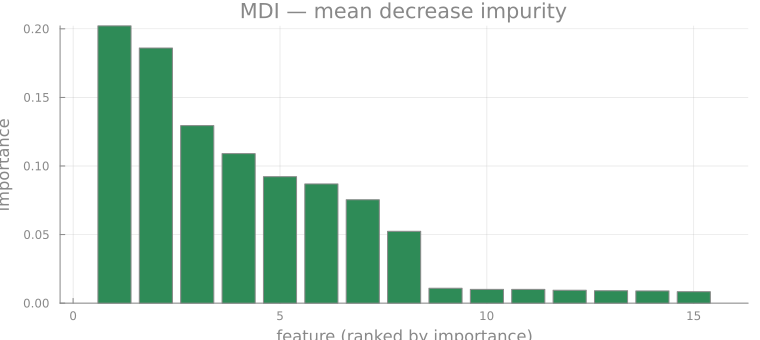

In [4]:
mdi = feature_importance_mdi(x, y; n_trees = 80, random_state = 1)
println("MDI: $(top_signal(mdi.mean))/$(n_signal) of the top features are real signal")
plot_importance(mdi.mean, "MDI — mean decrease impurity")

## 4. MDA — mean decrease accuracy (permutation)

MDA permutes each feature out-of-sample. Note a known quirk: when two features
are **redundant**, permuting one barely hurts (the model leans on its twin), so
MDA tends to *understate* redundant features — a substitution effect.

MDA: 8/8 of the top features are real signal


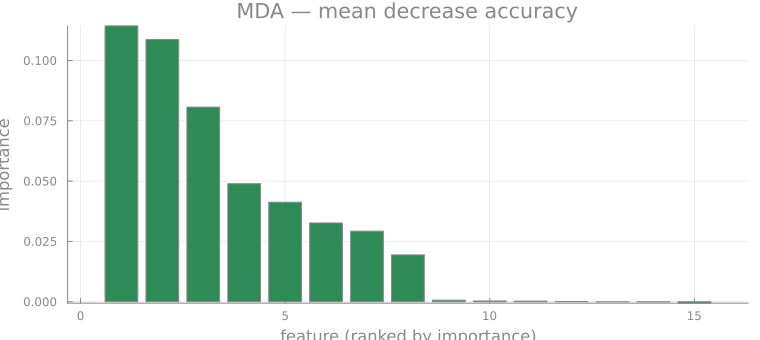

In [5]:
mda = feature_importance_mda(x, y; n_splits = 8, n_trees = 80, random_state = 1)
println("MDA: $(top_signal(mda.mean))/$(n_signal) of the top features are real signal")
plot_importance(mda.mean, "MDA — mean decrease accuracy")

## 5. SFI — single feature importance

SFI trains a model on **each feature alone**, so it is immune to substitution
effects (it never sees two features together).

SFI: 8/8 of the top features are real signal


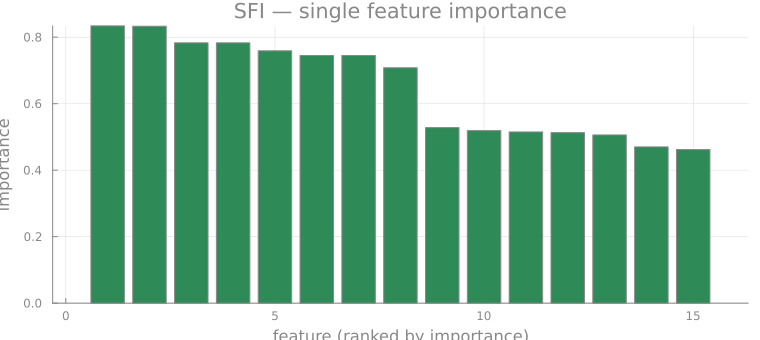

In [6]:
sfi = feature_importance_sfi(x, y; n_splits = 8, n_trees = 80, scoring = :accuracy)
println("SFI: $(top_signal(sfi.mean))/$(n_signal) of the top features are real signal")
plot_importance(sfi.mean, "SFI — single feature importance")

## 6. Orthogonal features &amp; method agreement

Collinear (redundant) features split a model's attention. `orthogonal_features`
(PCA) builds uncorrelated features that sidestep this. The **weighted Kendall-τ**
then measures how strongly two importance rankings agree (weighting top ranks most).

In [7]:
orth, eigenvalues, eigenvectors, cumulative = orthogonal_features(x; variance_threshold = 0.95)
println("PCA: $(size(orth, 2)) orthogonal components capture 95% of variance ",
        "(from $(size(x, 2)) raw features)")

mda_rank = Float64.(invperm(sortperm(mda.mean; rev = true)))   # rank 1 = most important
tau = calculate_weighted_tau(mdi.mean, mda_rank)
println("MDI vs MDA agreement (weighted Kendall-τ): ", round(tau; digits = 3))

PCA: 12 orthogonal components capture 95% of variance 

(from 15 raw features)
MDI vs MDA agreement (weighted Kendall-τ): 

0.857


## Takeaways

- **MDI** is fast and ranks the signal cleanly, but it is computed *in-sample* —
  treat its magnitudes as optimistic.
- **MDA** is out-of-sample and more trustworthy, but **understates redundant
  features** because of substitution effects.
- **SFI** evaluates features in isolation, sidestepping substitution — useful as a
  cross-check.
- **Orthogonal (PCA) features** remove collinearity; the **weighted-τ** quantifies
  how much two rankings agree.

From `RiskLabAI`: `get_test_dataset`, `feature_importance_mdi` / `_mda` / `_sfi`,
`orthogonal_features`, and `calculate_weighted_tau`.